In [4]:
# pip install torch
# pip install transformers
# pip install ipywidgets
# pip install einops
# pip install triton

In [1]:
# pip install datasets accelerate scikit-learn

In [1]:
# pip install "numpy<2"

In [1]:
# import sys
# import os

# site_packages = None
# for p in sys.path:
#     if 'site-packages' in p.lower():
#         site_packages = p
#         break

# if site_packages:
#     triton_path = os.path.join(site_packages, 'triton')
#     os.makedirs(triton_path, exist_ok=True)
#     open(os.path.join(triton_path, '__init__.py'), 'a').close()

In [5]:
# pip install --user torch

In [3]:
# pip install --user transformers

In [5]:
# pip install --user einops

In [5]:
# pip install --user transformers==4.36.2 tokenizers==0.15.2 accelerate==0.26.1 datasets==2.16.1

In [1]:
# %pip install --user scikit-learn

In [2]:
# %pip install --user seaborn

In [3]:
# %pip uninstall -y triton

In [4]:
# %pip install --user transformers==4.29.2 tokenizers==0.13.3

In [1]:
# EJEMPLO DE FUNCIONAMIENTO DE DNABERT-2-117M

import torch
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("zhihan1996/DNABERT-2-117M", trust_remote_code=True)

model = AutoModel.from_pretrained("zhihan1996/DNABERT-2-117M", trust_remote_code=True)

model = model.to("cuda")

dna = "ACGTAGCATCGGATCTATCTATCGACACTTGGTTATCGATCTACGAGCATCTCGTTAGC"
inputs = tokenizer(dna, return_tensors = 'pt')["input_ids"]

inputs = inputs.to("cuda")

hidden_states = model(inputs)[0] 

embedding_mean = torch.mean(hidden_states[0], dim=0)
print(embedding_mean.shape) 

embedding_max = torch.max(hidden_states[0], dim=0)[0]
print(embedding_max.shape)

/home/jbs1009/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jbs1009/.local/lib/python3.8/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/jbs1009/.local/lib/python3.8/site-packages/transformers/modeling_utils.py:446: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, th

torch.Size([768])
torch.Size([768])


In [ ]:
import pandas as pd
import numpy as np
import requests
import time

base = pd.read_csv("datosGene4PD/base_nueva_1332.csv", sep = ",", index_col = False)

etiqueta_binaria = {"Sano": 0, "Riesgo_PD": 1}

base["Etiqueta"] = base["Etiqueta"].map(etiqueta_binaria)

base = base.rename(columns = {"Etiqueta": "labels"})

base

In [ ]:
# PRUEBA DEL TRANSFORMER CON BASE DE REGIONES FLANQUEANTES

import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer, AutoConfig, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
import torch
import gc

hf_dataset = Dataset.from_pandas(base)
dataset_dividido = hf_dataset.train_test_split(test_size = 0.2)

tokenizer = AutoTokenizer.from_pretrained("zhihan1996/DNABERT-2-117M", trust_remote_code=True)

def tokeniza_secuencias(base):
    return tokenizer(base["Secuencia"])

hf_base_tokenizada = dataset_dividido.map(
    tokeniza_secuencias, 
    batched=True, 
    batch_size=10  
)

gc.collect() 

config = AutoConfig.from_pretrained(
    "zhihan1996/DNABERT-2-117M", 
    trust_remote_code=True, 
    num_labels=2
)

config.pad_token_id = tokenizer.pad_token_id
config.hidden_dropout_prob = 0.2
config.attention_probs_dropout_prob = 0.2

model = AutoModelForSequenceClassification.from_pretrained(
    "zhihan1996/DNABERT-2-117M", 
    config=config,
    trust_remote_code=True
)

data_collator = DataCollatorWithPadding(tokenizer = tokenizer)

training_args = TrainingArguments(
    output_dir="./resultados_dnabert_flancos",  
    learning_rate=5e-5,                 
    per_device_train_batch_size=4,      
    per_device_eval_batch_size=4,
    num_train_epochs=15,                 
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    evaluation_strategy="epoch",             
    save_strategy="epoch",
    fp16=True,                   
    dataloader_num_workers=0,    
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_base_tokenizada["train"],
    eval_dataset=hf_base_tokenizada["test"],
    data_collator=data_collator,
)


trainer.train()

1. Cargando datos...
2. Cargando Tokenizer...
Tokenizando secuencias poco a poco...


/home/jbs1009/.local/lib/python3.8/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Map: 100%|██████████| 306/306 [00:00<00:00, 2503.64 examples/s]


3. Preparando la configuración...
4. Cargando el Modelo Clasificador...


/home/jbs1009/.local/lib/python3.8/site-packages/transformers/modeling_utils.py:446: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(checkpoint_file, map_loc

5. Configurando el motor de entrenamiento...
6. ¡Iniciando entrenamiento final!


Epoch,Training Loss,Validation Loss
1,No log,0.691309
2,0.702100,0.692076
3,0.702100,0.692075
4,0.700500,0.714807
5,0.696600,0.702330
6,0.696600,0.699557
7,0.702100,0.699233
8,0.702100,0.692019
9,0.695900,0.694827
10,0.694500,0.698622


/home/jbs1009/.local/lib/python3.8/site-packages/transformers/trainer.py:2700: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)
/home/jbs1009/.local/lib/python3.8/site-packages/transformers/trainer.py:2700: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)
/home/jbs1009/.local/lib/python3.8/site-packages/transformers/trainer.py:2700: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)
/home/jbs1009/.local/lib/python3.8/site-packages/transformers/trainer.py:2700: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Plea

TrainOutput(global_step=4590, training_loss=0.6967565864779072, metrics={'train_runtime': 971.4232, 'train_samples_per_second': 18.9, 'train_steps_per_second': 4.725, 'total_flos': 1.258738684377264e+16, 'train_loss': 0.6967565864779072, 'epoch': 15.0})

In [ ]:
# PRUEBA CONGELANDO EL MODELO ENTERO MENOS LAS DOS ÚLTIMAS CAPAS

import pandas as pd
import numpy as np
from datasets import Dataset
from transformers import AutoTokenizer, AutoConfig, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
import torch
import gc


hf_dataset = Dataset.from_pandas(base)
dataset_dividido = hf_dataset.train_test_split(test_size=0.2)

tokenizer = AutoTokenizer.from_pretrained("zhihan1996/DNABERT-2-117M", trust_remote_code=True)

def tokeniza_secuencias(base):
    return tokenizer(base["Secuencia"])

hf_base_tokenizada = dataset_dividido.map(tokeniza_secuencias, batched=True, batch_size=10)
gc.collect()

config = AutoConfig.from_pretrained("zhihan1996/DNABERT-2-117M", trust_remote_code=True, num_labels=2)
config.pad_token_id = tokenizer.pad_token_id
config.hidden_dropout_prob = 0.2       
config.attention_probs_dropout_prob = 0.2


model = AutoModelForSequenceClassification.from_pretrained(
    "zhihan1996/DNABERT-2-117M", 
    config=config,
    trust_remote_code=True
)


for name, param in model.named_parameters():
    if "classifier" in name or "layer.11" in name: 
        param.requires_grad = True
    else:
        param.requires_grad = False


def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    if isinstance(predictions, tuple):
        predictions = predictions[0]
        
    preds = np.argmax(predictions, axis=1)
    return {"accuracy": np.mean(preds == labels)}


data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./resultados_dnabert_congelado",
    learning_rate=5e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=15,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    fp16=True,
    dataloader_num_workers=0,
    metric_for_best_model="accuracy",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_base_tokenizada["train"],
    eval_dataset=hf_base_tokenizada["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics, 
)

trainer.train()

/home/jbs1009/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1. Cargando secuencias flanqueantes...
2. Cargando Tokenizer...


/home/jbs1009/.local/lib/python3.8/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Tokenizando...


Map: 100%|██████████| 306/306 [00:00<00:00, 2576.02 examples/s]


...

❄️ CONGELANDO CAPAS: Dejando solo la cabeza clasificadora activa...
5. Configurando el motor...
6. ¡Iniciando entrenamiento con Extracción de Características!


/home/jbs1009/.cache/huggingface/modules/transformers_modules/zhihan1996/DNABERT-2-117M/7bce263b15377fc15361f52cfab88f8b586abda0/bert_layers.py:433: UserWarning: Increasing alibi size from 512 to 1003
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.696605,0.490196
2,0.697500,0.693436,0.490196
3,0.697500,0.697649,0.509804
4,0.697700,0.693101,0.509804
5,0.696600,0.693426,0.490196
6,0.696600,0.693273,0.490196


/home/jbs1009/.local/lib/python3.8/site-packages/transformers/trainer.py:2700: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)
/home/jbs1009/.local/lib/python3.8/site-packages/transformers/trainer.py:2700: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)
/home/jbs1009/.local/lib/python3.8/site-packages/transformers/trainer.py:2700: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)
/home/jbs1009/.local/lib/python3.8/site-packages/transformers/trainer.py:2700: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Plea

KeyboardInterrupt: 

In [ ]:
# PRUEBA DE HACER MAX POOLING

import pandas as pd
import numpy as np
from datasets import Dataset
from transformers import AutoModel, AutoTokenizer, AutoConfig, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
from transformers.modeling_outputs import SequenceClassifierOutput
import torch
import torch.nn as nn
import torch.nn.functional as F
import gc


hf_dataset = Dataset.from_pandas(base)
dataset_dividido = hf_dataset.train_test_split(test_size=0.2)

tokenizer = AutoTokenizer.from_pretrained("zhihan1996/DNABERT-2-117M", trust_remote_code=True)

def tokeniza_secuencias(base):
    return tokenizer(base["Secuencia"], truncation = True, max_length = 1000)

hf_base_tokenizada = dataset_dividido.map(tokeniza_secuencias, batched=True, batch_size=10)

gc.collect()

config = AutoConfig.from_pretrained("zhihan1996/DNABERT-2-117M", trust_remote_code=True, num_labels=2)
config.pad_token_id = tokenizer.pad_token_id
config.hidden_dropout_prob = 0.2       
config.attention_probs_dropout_prob = 0.2


class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma # <--- Esta es la "Lupa". Un valor de 2 o 3 fuerza al modelo a mirar lo difícil.

    def forward(self, inputs, targets):
        # Calculamos el error normal
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        # Calculamos la probabilidad de acierto del modelo
        pt = torch.exp(-ce_loss)
        # Aplicamos la fórmula Focal: Castigamos exponencialmente los errores donde el modelo estaba muy seguro pero falló
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()
    

class DNABERT2MaxPooling(nn.Module):
    def __init__(self, checkpoint="zhihan1996/DNABERT-2-117M", num_labels=2):
        super().__init__()
        self.base_model = AutoModel.from_pretrained(checkpoint, config=config, trust_remote_code=True)
        hidden_size = self.base_model.config.hidden_size 
        
        self.classifier = nn.Linear(hidden_size, num_labels)
        
        # ---> ¡AQUÍ ESTÁ EL CAMBIO! Usamos nuestra Focal Loss en lugar de la estándar <---
        self.loss_fct = FocalLoss(gamma=2.0)

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        outputs = self.base_model(input_ids=input_ids, attention_mask=attention_mask, **kwargs)
        
        if isinstance(outputs, tuple):
            last_hidden_state = outputs[0]
        else:
            last_hidden_state = outputs.last_hidden_state 
            
        if attention_mask is not None:
            mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
            last_hidden_state[mask_expanded == 0] = -1e9 
        
        max_pooled, _ = torch.max(last_hidden_state, dim=1)
        logits = self.classifier(max_pooled)
        
        loss = None
        if labels is not None:
            loss = self.loss_fct(logits, labels) # El modelo sufre el nuevo castigo
            
        return SequenceClassifierOutput(loss=loss, logits=logits)

# Instanciamos nuestra nueva creación
model = DNABERT2MaxPooling()

for name, param in model.named_parameters():
    
    if "classifier" in name or "layer.9." in name or "layer.10." in name or "layer.11." in name: 
        param.requires_grad = True

    else:
        param.requieres_grad = False


def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    if isinstance(predictions, tuple):
        predictions = predictions[0]
        
    preds = np.argmax(predictions, axis=1)
    return {"accuracy": np.mean(preds == labels)}


data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./resultados_dnabert_congelado",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=15,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    fp16=True,
    dataloader_num_workers=0,
    metric_for_best_model="accuracy",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_base_tokenizada["train"],
    eval_dataset=hf_base_tokenizada["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics, 
)

trainer.train()

/home/jbs1009/.local/lib/python3.8/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
loading file tokenizer.json from cache at /home/jbs1009/.cache/huggingface/hub/models--zhihan1996--DNABERT-2-117M/snapshots/7bce263b15377fc15361f52cfab88f8b586abda0/tokenizer.json
loading file added_tokens.json from cache at None
loading file special_tokens_map.json from cache at None
loading file tokenizer_config.json from cache at /home/jbs1009/.cache/huggingface/hub/models--zhihan1996--DNABERT-2-117M/snapshots/7bce263b15377fc15361f52cfab88f8b586abda0/tokenizer_config.json
Map: 100%|██████████| 284/284 [00:00<00:00, 2438.44 examples/s]
loading configuration file config.json from cache at /home/jbs1009/.cache/huggingface/hub/models--zhihan1996--DNABERT-2-117M/snapshots/7bce263b15377fc15361f52cfab88

❄️ CONGELANDO CAPAS: Protegiendo el conocimiento base...


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.174202,0.482394
2,0.177500,0.178582,0.517606
3,0.177500,0.174999,0.517606
4,0.177100,0.175787,0.482394
5,0.177100,0.173131,0.517606
6,0.176300,0.173223,0.517606
7,0.176300,0.173389,0.482394
8,0.174400,0.175145,0.482394
9,0.174400,0.173401,0.482394
10,0.174400,0.179782,0.482394


The following columns in the evaluation set don't have a corresponding argument in `DNABERT2MaxPooling.forward` and have been ignored: token_type_ids, Secuencia. If token_type_ids, Secuencia are not expected by `DNABERT2MaxPooling.forward`,  you can safely ignore this message.
***** Running Evaluation *****
  Num examples = 284
  Batch size = 4
Saving model checkpoint to ./resultados_dnabert_congelado/checkpoint-284
Trainer.model is not a `PreTrainedModel`, only saving its state dict.
/home/jbs1009/.local/lib/python3.8/site-packages/transformers/trainer.py:2700: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)
The following columns in the evaluation set don't have a corresponding argument in `DNABERT2MaxPooling.forward` and have been ignored: token_type_ids, Secuencia. If token_type_ids, Secuencia are not expected by `DNABERT2MaxPoo

TrainOutput(global_step=4260, training_loss=0.17517317382382674, metrics={'train_runtime': 872.4775, 'train_samples_per_second': 19.496, 'train_steps_per_second': 4.883, 'total_flos': 0.0, 'train_loss': 0.17517317382382674, 'epoch': 15.0})

In [ ]:
# PRUEBA PARA TROCEAR SECUENCIAS COMPLETAS Y ENTRENAR MODELO CLÁSICO (RANDOM FOREST)

import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

tokenizer = AutoTokenizer.from_pretrained("zhihan1996/DNABERT-2-117M", trust_remote_code=True)
model = AutoModel.from_pretrained("zhihan1996/DNABERT-2-117M", trust_remote_code=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

def trocea_secuencia(secuencia, chunk_size = 1000, overlap = 200):
    
    if len(secuencia) <= chunk_size:
        return [secuencia]
        
    chunks = []
    step = chunk_size - overlap
    
    for i in range(0, len(secuencia) - chunk_size + 1, step):
        chunks.append(secuencia[i:i + chunk_size])
        
    if (len(secuencia) - chunk_size) % step != 0:
        chunks.append(secuencia[-chunk_size:])
        
    return chunks


def get_sequence_embedding(long_sequence):
    chunks = trocea_secuencia(long_sequence)
    chunk_embeddings = []
    
    # torch.no_grad() es el salvavidas: prohíbe a PyTorch almacenar memoria para entrenar
    with torch.no_grad():
        for chunk in chunks:
            # Tokenizamos el trocito
            inputs = tokenizer(chunk, return_tensors="pt", truncation=True, max_length=1000)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            
            # Lo pasamos por el modelo
            outputs = model(**inputs)
            
            # Cogemos el token [CLS] (el resumen del trozo) o hacemos mean pooling
            if isinstance(outputs, tuple):
                hidden_state = outputs[0]
            else:
                hidden_state = outputs.last_hidden_state
                
            # Hacemos la media de la señal de este trozo
            chunk_embed = torch.mean(hidden_state, dim=1).squeeze().cpu().numpy()
            chunk_embeddings.append(chunk_embed)
            
    final_patient_embedding = np.mean(chunk_embeddings, axis=0)
    return final_patient_embedding


todos_los_embeddings = []

for index, row in tqdm(base.iterrows(), total = len(base)):
    seq_gigante = row["Secuencia"]
    vector_paciente = get_sequence_embedding(seq_gigante)
    todos_los_embeddings.append(vector_paciente)

np.save("embeddings_genes_completos.npy", todos_los_embeddings)
np.save("etiquetas_genes_completos.npy", base["labels"].values)

/home/jbs1009/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jbs1009/.local/lib/python3.8/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Cargando modelo...


/home/jbs1009/.local/lib/python3.8/site-packages/transformers/modeling_utils.py:446: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(checkpoint_file, map_loc

Procesando pacientes...


  0%|          | 0/1332 [00:00<?, ?it/s]/home/jbs1009/.cache/huggingface/modules/transformers_modules/zhihan1996/DNABERT-2-117M/7bce263b15377fc15361f52cfab88f8b586abda0/bert_layers.py:433: UserWarning: Increasing alibi size from 512 to 1000
  warnings.warn(
100%|██████████| 1332/1332 [2:50:47<00:00,  7.69s/it]  


KeyError: 'etiqueta'

In [9]:
np.save("etiquetas_genes_completos.npy", base["labels"].values)

Total de secuencias: 1332
Variables matemáticas por secuencia: 768
Accuracy: 0.4419
               precision    recall  f1-score   support

     Sano (0)       0.47      0.85      0.60       133
Riesgo_PD (1)       0.20      0.04      0.06       134

     accuracy                           0.44       267
    macro avg       0.33      0.44      0.33       267
 weighted avg       0.33      0.44      0.33       267



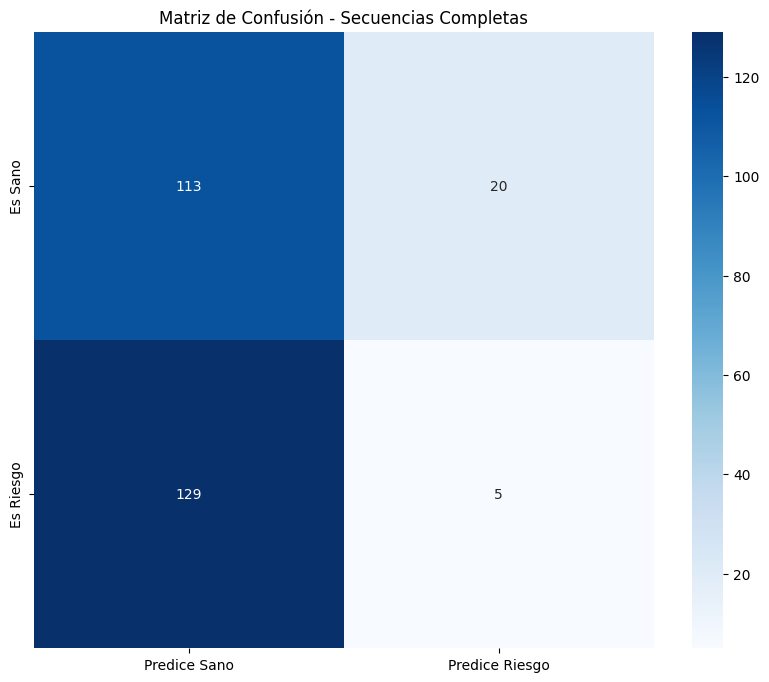

In [28]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


X = np.load("embeddings_genes_completos.npy")
y = np.load("etiquetas_genes_completos.npy")

print(f"Total de secuencias: {X.shape[0]}")
print(f"Variables matemáticas por secuencia: {X.shape[1]}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2026, stratify=y)

modelo = RandomForestClassifier(
    n_estimators=1500,
    max_depth=20,
    random_state=2026,
    n_jobs=-1)

modelo.fit(X_train, y_train)

predicciones = modelo.predict(X_test)

accuracy = accuracy_score(y_test, predicciones)
print(f"Accuracy: {accuracy:.4f}")

print(classification_report(y_test, predicciones, target_names=["Sano (0)", "Riesgo_PD (1)"]))

cm = confusion_matrix(y_test, predicciones)

plt.figure(figsize = (10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Predice Sano", "Predice Riesgo"], yticklabels=["Es Sano", "Es Riesgo"])
plt.title("Matriz de Confusión - Secuencias Completas")
plt.show()

In [23]:
params_grid = {
    "n_estimators": [1000, 1500, 2000, 5000, 10000, 50000],
    "max_depth": [20, 30, 50, 100, 200, 2500]
}

In [24]:
modelo_grid_search = GridSearchCV(modelo, params_grid, cv = 5, scoring = "accuracy", verbose = 5, n_jobs = -1)
modelo_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV 5/5] END ...max_depth=30, n_estimators=1000;, score=0.418 total time=   7.3s
[CV 3/5] END ...max_depth=30, n_estimators=1000;, score=0.413 total time=   7.6s
[CV 1/5] END ...max_depth=30, n_estimators=1000;, score=0.455 total time=   8.1s
[CV 1/5] END ...max_depth=50, n_estimators=1000;, score=0.455 total time=   8.1s
[CV 2/5] END ...max_depth=50, n_estimators=1000;, score=0.418 total time=   8.3s
[CV 2/5] END ...max_depth=30, n_estimators=1000;, score=0.418 total time=   9.0s
[CV 2/5] END ..max_depth=200, n_estimators=1000;, score=0.418 total time=   9.1s
[CV 4/5] END ...max_depth=20, n_estimators=1000;, score=0.418 total time=   9.6s
[CV 5/5] END ...max_depth=20, n_estimators=1000;, score=0.418 total time=  10.1s
[CV 3/5] END ...max_depth=50, n_estimators=1000;, score=0.413 total time=  10.4s
[CV 3/5] END ...max_depth=20, n_estimators=1000;, score=0.413 total time=  10.1s
[CV 4/5] END ...max_depth=30, n_estimators=1000

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(max_depth=20, n_estimators=1500,
                                              n_jobs=-1, random_state=2026),
             n_jobs=-1,
             param_grid={'max_depth': [20, 30, 50, 100, 200, 2500],
                         'n_estimators': [1000, 1500, 2000, 5000, 10000,
                                          50000]},
             scoring='accuracy', verbose=5)

In [25]:
modelo_grid_search.best_params_

{'max_depth': 20, 'n_estimators': 1000}

In [26]:
y_pred_best = modelo_grid_search.predict(X_test)

In [29]:
accuracy = accuracy_score(y_test, y_pred_best)
print("Accuracy:", accuracy)
precision = precision_score(y_test, y_pred_best)
print("Precision:", precision)
recall = recall_score(y_test, y_pred_best)
print("Recall:", recall)
f1 = f1_score(y_test, y_pred_best)
print("F1 Score:", f1)

Accuracy: 0.4419475655430712
Precision: 0.2
Recall: 0.03731343283582089
F1 Score: 0.06289308176100629


In [3]:
import pandas as pd
print("Longitud máxima de ADN:", base["Secuencia"].str.len().max())
print("Longitud media de ADN:", base["Secuencia"].str.len().mean())

Longitud máxima de ADN: 2172912
Longitud media de ADN: 214061.43843843843


In [ ]:
trainer.save_model("./mi_modelo_dnabert_entrenado")
print("✅ ¡Entrenamiento finalizado y modelo guardado con éxito!")

In [26]:
from datasets import Dataset
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding

In [14]:
hf_base = Dataset.from_pandas(base)

In [15]:
hf_base

Dataset({
    features: ['Secuencia', 'labels'],
    num_rows: 1332
})

In [19]:
hf_base_split = hf_base.train_test_split(test_size = 0.20)

In [20]:
hf_base_split

DatasetDict({
    train: Dataset({
        features: ['Secuencia', 'labels'],
        num_rows: 1065
    })
    test: Dataset({
        features: ['Secuencia', 'labels'],
        num_rows: 267
    })
})

In [21]:
tokenizer = AutoTokenizer.from_pretrained("zhihan1996/DNABERT-2-117M", trust_remote_code = True)

In [28]:
data_collator = DataCollatorWithPadding(tokenizer = tokenizer)

In [27]:
def tokeniza_secuencias(base):
    return tokenizer(base["Secuencia"])

In [1]:
# hf_base_tokenizada = hf_base_split.map(tokeniza_secuencias, batched = True)

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import requests
import time

base = pd.read_csv("datosGene4PD/base_flanqueantes_20_OR_1418_con_rsid.csv", sep = ",", index_col = False)
etiqueta_binaria = {"Sano": 0, "Riesgo_PD": 1}
base["Etiqueta"] = base["Etiqueta"].map(etiqueta_binaria)
base = base.rename(columns = {"Etiqueta": "labels"})


X_seq = base["Secuencia"]
y = base["labels"].values
grupos_rsid = base["rsID"].values

encoding = {"a": [1, 0, 0, 0], "c": [0, 1, 0, 0], "g": [0, 0, 1, 0], "t": [0, 0, 0, 1]}

def one_hot_encode_sequence(seq):
    return np.array([encoding[nuc] for nuc in seq])

X_oh = np.array([one_hot_encode_sequence(seq) for seq in X_seq])
X_oh = X_oh.reshape(X_oh.shape[0], -1)


def kmeriza(sequence, k=3):
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

base['kmers'] = X_seq.apply(lambda seq: ' '.join(kmeriza(seq, k=3)))
vectorizer = CountVectorizer()
X_kmers_sparse = vectorizer.fit_transform(base["kmers"])
X_kmers = X_kmers_sparse.toarray()


gss = GroupShuffleSplit(n_splits = 1, test_size = 0.2, random_state = 2026)

train_id, test_id = next(gss.split(X_seq, y, groups = grupos_rsid))

X_train_oh, X_test_oh = X_oh[train_id], X_oh[test_id]

X_train_kmers, X_test_kmers = X_kmers[train_id], X_kmers[test_id]

y_train, y_test = y[train_id], y[test_id]

model_oh = MLPClassifier(hidden_layer_sizes=(20,), max_iter=300, random_state=2026)
model_kmers = MLPClassifier(hidden_layer_sizes=(20,), max_iter=300, random_state=2026)

model_oh.fit(X_train_oh, y_train)
model_kmers.fit(X_train_kmers, y_train)

y_pred_proba_oh = model_oh.predict_proba(X_test_oh)[:, 1]
y_pred_proba_kmers = model_kmers.predict_proba(X_test_kmers)[:, 1]

auc_score_oh = roc_auc_score(y_test, y_pred_proba_oh)
auc_score_kmers = roc_auc_score(y_test, y_pred_proba_kmers)

print(f'AUC-ROC One-Hot: {auc_score_oh:.4f}')
print(f'AUC-ROC k-mers: {auc_score_kmers:.4f}')

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2026, stratify=y)

# print(X_train.shape)
# print(X_test.shape)
# print(y_train.shape)
# print(y_test.shape)

# modelo = RandomForestClassifier(
#     n_estimators=1500,
#     max_depth=20,
#     random_state=2026,
#     n_jobs=-1)

# modelo.fit(X_train, y_train)

# predicciones = modelo.predict(X_test)

# accuracy = accuracy_score(y_test, predicciones)
# print(f"Accuracy: {accuracy:.4f}")

# print(classification_report(y_test, predicciones, target_names=["Sano (0)", "Riesgo_PD (1)"]))

# cm = confusion_matrix(y_test, predicciones)

# plt.figure(figsize = (10,8))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Predice Sano", "Predice Riesgo"], yticklabels=["Es Sano", "Es Riesgo"])
# plt.title("Matriz de Confusión - Secuencias Completas")
# plt.show()


#PRUEBA

PRUEBAS CON VENTANA 50

In [4]:
import pandas as pd
import numpy as np
import requests
import time

base = pd.read_csv("/home/jbs1009/TFM/datosGene4PD/base_flanqueantes_50_OR_3109_con_rsid_extendida.csv", sep = ",", index_col = False)

etiqueta_binaria = {"Sano": 0, "Riesgo_PD": 1}

base["labels"] = base["labels"].map(etiqueta_binaria)

base

,Secuencia,labels,rsID
0,tatattttcttttgtcacaggcttatttatattcatcttccactgt...,0,rs757765789
1,tatattttcttttgtcacaggcttatttatattcatcttccactgt...,1,rs757765789
2,agtgttttcaaagaatctattgattctaattgctaaccctttttat...,0,rs1994090
3,agtgttttcaaagaatctattgattctaattgctaaccctttttat...,1,rs1994090
4,caacccttatcctgaagctgcctaggggctaccagtcatctgtcaa...,0,rs2708453
...,...,...,...
3104,acagaagaagcagatgtcaccgtggggccactgatcttcctggaca...,0,rs200481427
3105,aggcatgagccaccatgcccagctgactgtgtctttcagagaactg...,0,rs74676082
3106,caccgtggggccactgatcttcctggacaggaggggtgaccatgaa...,0,rs143649134
3107,ctggtctccatggacacagaagatgtggtcaggtttgaggttggac...,0,rs142370942


In [4]:
# PRUEBA DEL TRANSFORMER CON BASE DE REGIONES FLANQUEANTES

import numpy as np
import pandas as pd
import torch
import gc
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, classification_report
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoConfig, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, EarlyStoppingCallback

base = pd.read_csv("/home/jbs1009/TFM/datosGene4PD/base_flanqueantes_50_OR_3109_con_rsid_extendida.csv", sep = ",", index_col = False)
etiqueta_binaria = {"Sano": 0, "Riesgo_PD": 1}
base["labels"] = base["labels"].map(etiqueta_binaria)

gss1 = GroupShuffleSplit(n_splits = 1, test_size = 0.2, random_state = 2026)
id_tv, id_test = next(gss1.split(base, base["labels"], groups = base["rsID"]))

base_tv = base.iloc[id_tv].reset_index(drop = True)
base_test = base.iloc[id_test].reset_index(drop = True)

gss2 = GroupShuffleSplit(n_splits = 1, test_size = 0.25, random_state = 2026)
id_train, id_val = next(gss2.split(base_tv, base_tv["labels"], groups = base_tv["rsID"]))

base_train = base_tv.iloc[id_train].reset_index(drop = True)
base_val = base_tv.iloc[id_val].reset_index(drop = True)

hf_dataset = DatasetDict({
    "train": Dataset.from_pandas(base_train),
    "validation": Dataset.from_pandas(base_val),
    "test": Dataset.from_pandas(base_test)
})





tokenizer = AutoTokenizer.from_pretrained("zhihan1996/DNABERT-2-117M", trust_remote_code=True)

def tokeniza_secuencias(batch):
    return tokenizer(batch["Secuencia"])

hf_base_tokenizada = hf_dataset.map(
    tokeniza_secuencias, 
    batched=True, 
    batch_size=10  
)
gc.collect() 


class_weights = compute_class_weight("balanced", classes = np.unique(base_train["labels"]), y = base_train["labels"])

weights_tensor = torch.tensor([1.0, 10.0], dtype = torch.float32)


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs = False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = torch.nn.CrossEntropyLoss(weight = weights_tensor.to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss
    


def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    if isinstance(predictions, tuple):
        logits = predictions[0]
    
    else:
        logits = predictions

    probs = torch.nn.functional.softmax(torch.tensor(logits), dim = -1).numpy()[:, 1]
    preds = np.argmax(logits, axis = 1)

    return {
        "roc_auc": roc_auc_score(labels, probs),
        "pr_auc": average_precision_score(labels, probs),
        "f1": f1_score(labels, preds)
    }

config = AutoConfig.from_pretrained(
    "zhihan1996/DNABERT-2-117M", 
    trust_remote_code=True, 
    num_labels=2
)

config.pad_token_id = tokenizer.pad_token_id
config.hidden_dropout_prob = 0.2
config.attention_probs_dropout_prob = 0.2

model = AutoModelForSequenceClassification.from_pretrained(
    "zhihan1996/DNABERT-2-117M", 
    config=config,
    trust_remote_code=True
)

# for name, param in model.named_parameters():
#     if "classifier" in name or "score" in name:
#         param.requires_grad = True

#     else:
#         param.requires_grad = False

# parametros_entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)

# print(f"Parámetros entrenables: {parametros_entrenables}")

data_collator = DataCollatorWithPadding(tokenizer = tokenizer)

training_args = TrainingArguments(
    output_dir="./resultados_dnabert_flancos",  
    learning_rate=2e-6,                 
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,      
    per_device_eval_batch_size=8,
    num_train_epochs=15,                 
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    evaluation_strategy="epoch",             
    save_strategy="epoch",
    fp16=True,                   
    dataloader_num_workers=0,
    load_best_model_at_end=True,
    metric_for_best_model="roc_auc",
    greater_is_better=True    
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=hf_base_tokenizada["train"],
    eval_dataset=hf_base_tokenizada["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=15)]
)


trainer.train()



print("EVALUACIÓN EN CONJUNTO DE TEST")

predicciones = trainer.predict(hf_base_tokenizada["test"])

if isinstance(predicciones.predictions, tuple):
    logits_test = predicciones.predictions[0]

else:
    logits_test = predicciones.predictions

labels_test = predicciones.label_ids

probs_test = torch.nn.functional.softmax(torch.tensor(logits_test), dim = 1).numpy()[:, 1]
preds_test = np.argmax(logits_test, axis = 1)

print(f"ROC-AUC Test: {roc_auc_score(labels_test, probs_test):.4f}")
print(f"PR-AUC Test: {average_precision_score(labels_test, probs_test):.4f}\n")

print(classification_report(labels_test, preds_test, target_names = ["Sano", "Riesgo_PD"]))

/home/jbs1009/.local/lib/python3.8/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Map: 100%|██████████| 625/625 [00:00<00:00, 7474.35 examples/s]
/home/jbs1009/.local/lib/python3.8/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/jbs1009/.local/lib/python3.8/site-packages/transformers/modeling_utils.py:446: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github

Epoch,Training Loss,Validation Loss,Roc Auc,Pr Auc,F1
0,No log,0.691375,0.501035,0.227564,0.000000
1,No log,0.695707,0.500000,0.227200,0.370274
2,No log,0.697163,0.500000,0.227200,0.370274
4,No log,0.698743,0.500000,0.227200,0.370274
4,0.694200,0.709401,0.500000,0.227200,0.370274
5,0.694200,0.712239,0.500000,0.227200,0.370274
6,0.694200,0.716375,0.500000,0.227200,0.370274
8,0.694200,0.713010,0.498965,0.227200,0.370274
8,0.692700,0.710252,0.501035,0.227564,0.370274
9,0.692700,0.709644,0.500000,0.227200,0.370274


/home/jbs1009/.local/lib/python3.8/site-packages/transformers/trainer.py:2700: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)
/home/jbs1009/.local/lib/python3.8/site-packages/transformers/trainer.py:2700: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)
/home/jbs1009/.local/lib/python3.8/site-packages/transformers/trainer.py:2700: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)
/home/jbs1009/.local/lib/python3.8/site-packages/transformers/trainer.py:2700: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Plea

EVALUACIÓN EN CONJUNTO DE TEST


/home/jbs1009/.local/lib/python3.8/site-packages/transformers/trainer.py:2700: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)


ROC-AUC Test: 0.5010
PR-AUC Test: 0.2260

              precision    recall  f1-score   support

        Sano       0.77      1.00      0.87       484
   Riesgo_PD       0.00      0.00      0.00       141

    accuracy                           0.77       625
   macro avg       0.39      0.50      0.44       625
weighted avg       0.60      0.77      0.68       625



/home/jbs1009/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/jbs1009/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/jbs1009/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
